In [104]:
import numpy as np

In [105]:
H_1 = np.array([[1, 1],
                [1, -1]])/np.sqrt(2)

def normalize_vector(vector):
    norm = np.linalg.norm(vector)
    if norm != 0:
        return vector / norm
    return vector

def tensor_product(matrix, n):
    result = matrix
    for _ in range(n - 1):
        result = np.kron(result, matrix)
    return result

def oracle(n, ids):
    matrix = np.eye(2**n)
    for i in ids:
        matrix[i, i] = -1
    return matrix

def circuit(*matrices):
    result = matrices[0]
    for matrix in matrices[1:]:
        result = np.dot(result, matrix)
    return normalize_vector(result)

def start_vector(n):
    vector = np.zeros(2**n)  # Inizializza il vettore con zeri
    vector[0] = n         # Imposta il primo elemento a N
    return vector

def print_vector(array):
    # Print header
    print(f"{'Index':>5} {'Component':>10} {'Probability':>10}")
    print("-" * 30)  # Separator line
    
    for index, value in enumerate(array):
        print(f"{index:>5} {value:>10.4f} {value**2:>10.4f}")

In [106]:
n = 5
target = 10

H = tensor_product(H_1,n)

U = oracle(n,[0])

O = oracle(n,[target])

start = start_vector(n)

G = circuit(H,U,H,O)


In [107]:
state = circuit(start,H)

    
# Loop to perform circuit operation multiple times and print
for i in range(1, 19):  # Loop from 1 to 7
    matrices = [G] * i  # Create a list with 'i' number of G matrices
    result = circuit(state, *matrices)  # Pass all 'i' G matrices to circuit
    print(f"After {i} G matrix/matrices:")
    print(f"{result[target]**2:>10.4f}")

After 1 G matrix/matrices:
    0.0312
After 2 G matrix/matrices:
    0.2583
After 3 G matrix/matrices:
    0.6024
After 4 G matrix/matrices:
    0.8969
After 5 G matrix/matrices:
    0.9992
After 6 G matrix/matrices:
    0.8596
After 7 G matrix/matrices:
    0.5459
After 8 G matrix/matrices:
    0.2099
After 9 G matrix/matrices:
    0.0145
After 10 G matrix/matrices:
    0.0542
After 11 G matrix/matrices:
    0.3098
After 12 G matrix/matrices:
    0.6576
After 13 G matrix/matrices:
    0.9290
After 14 G matrix/matrices:
    0.9927
After 15 G matrix/matrices:
    0.8176
After 16 G matrix/matrices:
    0.4888
After 17 G matrix/matrices:
    0.1653
After 18 G matrix/matrices:
    0.0040


In [108]:
print(O)

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]


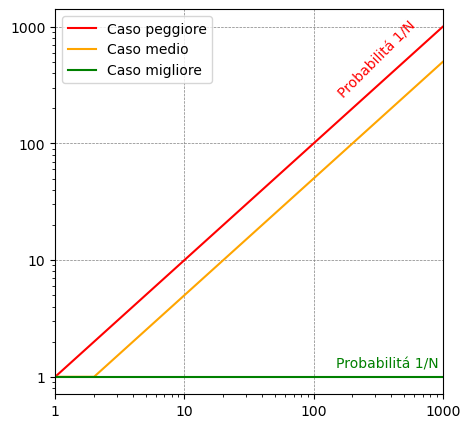

In [109]:
import matplotlib.pyplot as plt
import numpy as np

min_x = 1
max_x = 1000
# Definire l'intervallo di x
x = np.linspace(min_x,max_x, max_x-min_x+1)

# Creare il grafico
plt.figure(figsize=(5, 5))
plt.plot(x, x, label='Caso peggiore', color='red')
plt.plot(x, np.where(x > 1, x / 2, 1), label='Caso medio', color='orange')
plt.plot(x, np.ones_like(x), label='Caso migliore', color='green')

# Aggiungere testi vicino alle linee, abbassando le coordinate y
plt.text(150, 250, 'Probabilitá 1/N', color='red', rotation=45)
#plt.text(200, 75, 'N/2', color='orange', rotation=45)
plt.text(150, 1.2, 'Probabilitá 1/N', color='green')

# Aggiungere titolo e etichette
#plt.title('Complessità Temporale')
#plt.xlabel('Tuple nel Database')
#plt.ylabel('Chiamate all\' oracolo')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.xlim(min_x, max_x)
#plt.ylim(0)
plt.xscale('log')
plt.yscale('log')

# Impostare le etichette manualmente per evitare la notazione esponenziale
plt.xticks([1, 10, 100, 1000], ['1', '10', '100', '1000'])
plt.yticks([1, 10, 100, 1000], ['1', '10', '100', '1000'])


# Mostrare il grafico
plt.show()


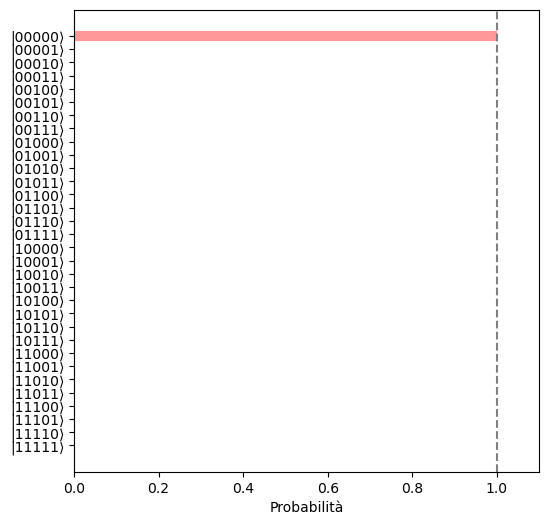

In [110]:
import matplotlib.pyplot as plt

# Definire gli stati quantistici
states = ['|00000⟩', '|00001⟩', '|00010⟩', '|00011⟩', '|00100⟩',
          '|00101⟩', '|00110⟩', '|00111⟩', '|01000⟩', '|01001⟩',
          '|01010⟩', '|01011⟩', '|01100⟩', '|01101⟩', '|01110⟩',
          '|01111⟩', '|10000⟩', '|10001⟩', '|10010⟩', '|10011⟩',
          '|10100⟩', '|10101⟩', '|10110⟩', '|10111⟩', '|11000⟩',
          '|11001⟩', '|11010⟩', '|11011⟩', '|11100⟩', '|11101⟩',
          '|11110⟩', '|11111⟩']

# Definire le probabilità (1 per |00000⟩, 0 per gli altri)
probabilities = [1] + [0] * (len(states) - 1)

# Invertire l'ordine delle liste
states.reverse()
probabilities.reverse()

# Creare l'istogramma orizzontale
plt.figure(figsize=(6, 6))

# Creare barre per ogni stato, colorando specificamente |01010⟩ di verde
colors = ['#FF9999' if state != '|10101⟩' else '#99FF99' for state in states]
plt.barh(states, probabilities, color=colors)

# Aggiungere titolo e etichette
#plt.title('Probabilità ')
plt.xlabel('Probabilità')
#plt.ylabel('Stati Quantistici')
plt.xlim(0, 1.1)  # Impostare i limiti dell'asse x

# Mostrare l'istogramma
# Aggiungere una linea orizzontale a y = 1.0
plt.axvline(x=1.0, color='gray', linestyle='--', label='y = 1.0')

plt.show()


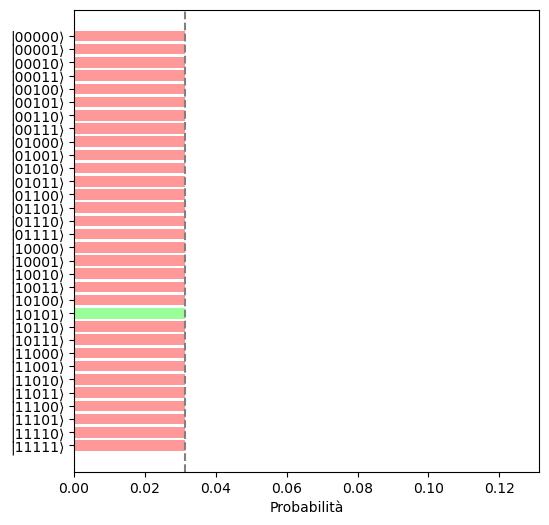

In [111]:
import matplotlib.pyplot as plt

# Definire gli stati quantistici
states = ['|00000⟩', '|00001⟩', '|00010⟩', '|00011⟩', '|00100⟩',
          '|00101⟩', '|00110⟩', '|00111⟩', '|01000⟩', '|01001⟩',
          '|01010⟩', '|01011⟩', '|01100⟩', '|01101⟩', '|01110⟩',
          '|01111⟩', '|10000⟩', '|10001⟩', '|10010⟩', '|10011⟩',
          '|10100⟩', '|10101⟩', '|10110⟩', '|10111⟩', '|11000⟩',
          '|11001⟩', '|11010⟩', '|11011⟩', '|11100⟩', '|11101⟩',
          '|11110⟩', '|11111⟩']


# Definire le probabilità equiprobabili
N = len(states)  # Numero totale di stati
probabilities = [1/N] * N  # Ogni stato ha probabilità 1/N

# Invertire l'ordine delle liste
states.reverse()
probabilities.reverse()

# Creare l'istogramma orizzontale
plt.figure(figsize=(6, 6))

# Creare barre per ogni stato, colorando specificamente |01010⟩ di verde
colors = ['#FF9999' if state != '|10101⟩' else '#99FF99' for state in states]
plt.barh(states, probabilities, color=colors)

# Aggiungere titolo e etichette
# plt.title('Probabilità Equiprobabili')
plt.xlabel('Probabilità')
plt.xlim(0, max(probabilities) + 0.1)  # Impostare i limiti dell'asse x

# Mostrare l'istogramma
# Aggiungere una linea orizzontale a y = 1.0
plt.axvline(x=1.0, color='gray', linestyle='--', label='y = 1.0')

# Mostrare l'istogramma
# Aggiungere una linea orizzontale a y = 1.0
plt.axvline(x=1/N, color='gray', linestyle='--', label=f'y = {1/N}')
plt.show()


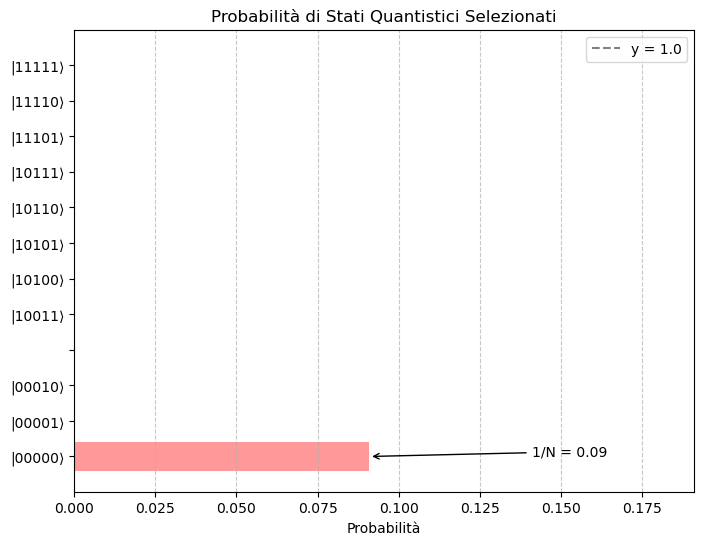

In [113]:
import matplotlib.pyplot as plt
import numpy as np

# Definire gli stati quantistici selezionati
selected_states = ['|00000⟩', '|00001⟩', '|00010⟩','|10011⟩',
          '|10100⟩', '|10101⟩', '|10110⟩', '|10111⟩', '|11101⟩',
          '|11110⟩', '|11111⟩']
# Aggiungere spazi per indicare che ci sono altri stati
states = ['|00000⟩', '|00001⟩', '|00010⟩',' ','|10011⟩',
          '|10100⟩', '|10101⟩', '|10110⟩', '|10111⟩',' ', '|11101⟩',
          '|11110⟩', '|11111⟩']

# Definire le probabilità (1 per |00000⟩, 0 per gli altri)
N = len(selected_states)  # Numero di stati selezionati
probabilities = [1/N] + [0] * (len(states) - 1)  # Probabilità per i selezionati, 0 per gli spazi

# Creare l'istogramma orizzontale
plt.figure(figsize=(8, 6))

# Creare barre per gli stati, colorando specificamente |01010⟩ di verde
colors = ['#FF9999' if state != '|01010⟩' else '#99FF99' for state in states]
plt.barh(states, probabilities, color=colors)

# Aggiungere titolo e etichette
plt.xlabel('Probabilità')
plt.xlim(0, max(probabilities) + 0.1)  # Impostare i limiti dell'asse x

# Aggiungere una linea orizzontale a y = 1.0
plt.axvline(x=1.0, color='gray', linestyle='--', label='y = 1.0')

# Annotare il punto 1/N sull'asse x
plt.annotate(f'1/N = {1/N:.2f}', xy=(1/N, 0), xytext=(1/N + 0.05, 0.02),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=10, color='black')

# Mostrare solo la linea di griglia a y = 1.0
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Mostrare l'istogramma
plt.legend()
plt.title('Probabilità di Stati Quantistici Selezionati')
plt.show()


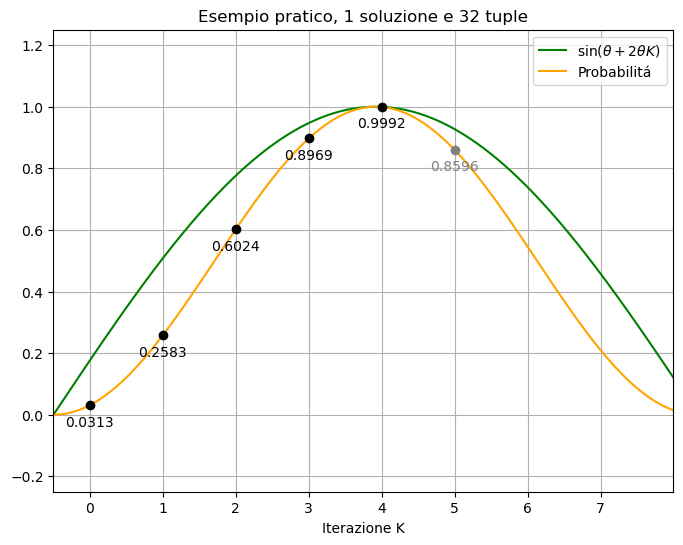

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Definizione del parametro a
a = np.arcsin(np.sqrt(1/32))

# Definizione della funzione f(x) e g(x)
def f(x):
    return np.sin(2 * a * x + a)

def g(x):
    return f(x)**2

min_x = -0.5
max_x = 8

# Intervallo di x
x = np.linspace(min_x, max_x, 1000)

# Creazione del grafico
plt.figure(figsize=(8, 6))

# Plot della funzione f(x)
plt.plot(x, f(x), label=r'$ \sin(θ+2θK)$', color='green')

# Plot della funzione g(x)
plt.plot(x, g(x), label=r'Probabilitá', color='orange')

# Aggiunta dei punti per x = 1, 2, 3, 4
x_points = [0, 1, 2, 3, 4]
f_points = f(np.array(x_points))
g_points = g(np.array(x_points))

# Segnare i punti su g(x)
plt.scatter(x_points, g_points, color='black', zorder=5)
for i, txt in enumerate(g_points):
    plt.annotate(f'{txt:.4f}', (x_points[i], g_points[i]), textcoords="offset points", xytext=(0, -15), ha='center', color='black')
    
    # Segnare i punti su g(x)
plt.scatter([5], [g(5)], color='gray', zorder=5)
plt.annotate(f'{g(5):.4f}', (5, g(5)), textcoords="offset points", xytext=(0, -15), ha='center', color='gray')


# Configurazione degli assi
plt.xlim(min_x, max_x)
plt.xticks(range(round(min_x), round(max_x)))  # Mostra ogni intero da -1 a 16
plt.ylim(-0.25, 1.25)

# Etichette e titolo
plt.xlabel('Iterazione K')
plt.title("Esempio pratico, 1 soluzione e 32 tuple")

# Legenda
plt.legend()

# Mostra il grafico
plt.grid(True)
plt.show()
